In [15]:
!pip install datasets[audio] librosa transformers

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
# %cd /content/drive/MyDrive/Speaker-Recognition-using-ResNet-Embeddings

# Data Preprocessing
loading data from local and Preprocess

In [18]:
from datasets import load_from_disk, concatenate_datasets, Audio
import glob

# loading data

drive_path = "/content/drive/MyDrive/Speaker-Recognition-using-ResNet-Embeddings/speaker_chunks/chunk_*"
chunk_paths = sorted(glob.glob(drive_path))

chunks = []
for path in chunk_paths:
    ds = load_from_disk(path)
    ds = ds.cast_column("audio_path", Audio(sampling_rate=16000))
    chunks.append(ds)

full_dataset = concatenate_datasets(chunks)

In [19]:
# split into train, dev, and test

split = full_dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = split["train"]

temp = split["test"].train_test_split(test_size=0.5, seed=42)
dev_dataset = temp["train"]
test_dataset = temp["test"]

print(len(train_dataset), len(dev_dataset), len(test_dataset))

20000 2500 2500


In [20]:
from datasets import disable_caching

# disable caching so no addition file are saved in drives

disable_caching()

Prepocess data by using Dataset_Builder script

In [21]:
import sys
from google.colab import drive

# Add the specific folder containing dataset.py to Python's search path
sys.path.append('/content/drive/MyDrive/Speaker_Recognition/Speaker-Recognition-using-ResNet-Embeddings')

from dataset import Dataset_Builder

# try the training set first

# config = {"shortest_duration": 4.0} # (optional)

train_builder = Dataset_Builder(train_dataset, **config)
train_builder.filter()
train_builder.preprocess()

Duration of cropped log-mel spectograms (input):  2.0  seconds


Filter:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/19231 [00:00<?, ? examples/s]

In [22]:
# Also do it for dev, and train

dev_builder = Dataset_Builder(dev_dataset, **config)
dev_builder.filter()
dev_builder.preprocess()

test_builder = Dataset_Builder(test_dataset, **config)
test_builder.filter()
test_builder.preprocess()

Duration of cropped log-mel spectograms (input):  2.0  seconds


Filter:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2402 [00:00<?, ? examples/s]

Duration of cropped log-mel spectograms (input):  2.0  seconds


Filter:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2407 [00:00<?, ? examples/s]

In [23]:
# get the proprocess data

train_dataset = train_builder.get_dataset()
dev_dataset = dev_builder.get_dataset()
test_dataset = test_builder.get_dataset()

print(len(train_dataset), len(dev_dataset), len(test_dataset))

19231 2402 2407


Demonstrate the log-Mel spectrogram before and after preprocessing. During preprocessing, the spectrogram is randomly cropped, resized, and normalized before being fed into the ResNet model.

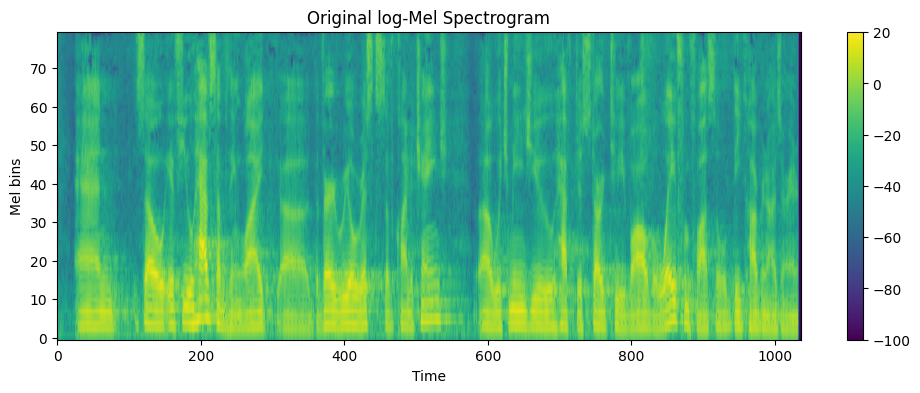

In [24]:
import torchaudio
import matplotlib.pyplot as plt

example = dev_dataset[6]
target_sr = 16000

mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=target_sr,
    n_fft=400,
    hop_length=160,
    n_mels=80
)

to_db = torchaudio.transforms.AmplitudeToDB()

samples = example["audio_path"].get_all_samples()

waveform = samples.data.float()
sr = samples.sample_rate

if waveform.ndim == 1:
    waveform = waveform.unsqueeze(0)

if sr != target_sr:
    waveform = torchaudio.functional.resample(
        waveform,
        orig_freq=sr,
        new_freq=target_sr
    )

mel = mel_transform(waveform)
log_mel = to_db(mel).squeeze(0)     # [80, T]

plt.figure(figsize=(12,4))
plt.imshow(log_mel.numpy(),origin="lower",aspect="auto")

plt.title("Original log-Mel Spectrogram")
plt.xlabel("Time")
plt.ylabel("Mel bins")
plt.colorbar()
plt.show()

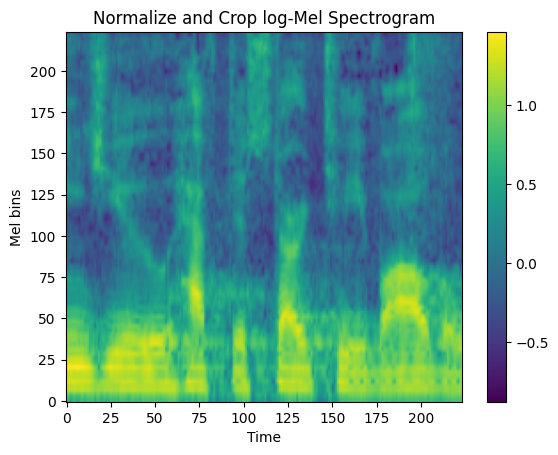

In [25]:
crop = example["log_mel"][0]
plt.imshow(crop,origin="lower",aspect="auto")

plt.title("Normalize and Crop log-Mel Spectrogram")
plt.xlabel("Time")
plt.ylabel("Mel bins")
plt.colorbar()
plt.show()

## Create DataLoaders

Create a custom collate function to convert the data into tensors. Then, build the train, dev, and test data loaders and check that the batch dimensions match the expected input format.

In [26]:
import torch
from torch.utils.data import DataLoader

NUM_CLASSES = 50
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def collate_fn(batch):
    log_mels = torch.stack([b["log_mel"] for b in batch])
    labels = torch.tensor([b["label"] for b in batch])
    return (log_mels, labels)

dataloader_train = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=False, # Already shuffled before saving
    collate_fn=collate_fn,
    pin_memory=True
)

dataloader_dev = DataLoader(
    dev_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn,
    pin_memory=True
)

In [27]:
batch = next(iter(dataloader_train))

print(batch[0].shape)  # [B, 1, 80, T]
print(batch[1].shape)          # [B]

torch.Size([32, 3, 224, 224])
torch.Size([32])


### Seed Everything

In [28]:
import random
import numpy as np
import torch

SEED = 42

def seed_everything(seed=42):
    # Python
    random.seed(seed)

    # NumPy
    np.random.seed(seed)

    # PyTorch CPU
    torch.manual_seed(seed)

    # PyTorch GPU
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    # CuDNN
    torch.backends.cudnn.deterministic = True

seed_everything(SEED)

In [29]:
from torchvision.models import resnet18
from torch.optim import AdamW
from torch.nn import CrossEntropyLoss

# lr: 5e-5
LR = 5e-5


model = resnet18(weights="DEFAULT")
model.fc = torch.nn.Linear(in_features=512, out_features=NUM_CLASSES, bias=True)
model.to(DEVICE)

optimizer = AdamW(params=model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)
ce_loss = CrossEntropyLoss()
print(sum([p.numel() for p in model.parameters() if p.requires_grad]))


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s]


11202162


In [30]:
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter(log_dir="runs/resnet18_3epoch")

In [31]:
# %load_ext tensorboard
# %tensorboard --logdir runs

In [32]:
from tqdm import tqdm
import torch

NUM_EPOCHS = 3
best_val_acc = 0.0

for epoch in range(1, NUM_EPOCHS+1):
    print(f"--- Epoch: {epoch} ---")

    model.train()

    for indx, (log_mels, labels) in tqdm(enumerate(dataloader_train), desc="Epoch Progress", total=len(dataloader_train)):
        log_mels = log_mels.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        preds = model(log_mels)
        loss = ce_loss(preds, labels)
        loss.backward()
        optimizer.step()

        global_step = (epoch-1)*len(dataloader_train) + indx
        writer.add_scalar("Loss/Train", loss.item(), global_step)

    scheduler.step()

    # ==================== VALIDATION PHASE ====================
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for log_mels, labels in tqdm(dataloader_dev, desc="Validation", total=len(dataloader_dev)):
            log_mels = log_mels.to(DEVICE)
            labels = labels.to(DEVICE)

            preds = model(log_mels)
            loss = ce_loss(preds, labels)

            val_loss += loss.item()
            val_correct += torch.sum(torch.argmax(preds, dim=1) == labels).item()
            val_total += len(labels)

    # Calculate final metrics for the epoch
    avg_val_loss = val_loss / len(dataloader_dev)
    val_acc = val_correct / val_total

    print(f"Epoch {epoch} finished | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Log to Tensorboard
    writer.add_scalar("Loss/Val", avg_val_loss, epoch)
    writer.add_scalar("Accuracy/Val", val_acc, epoch)

    # 1. Still track and save the absolute "best" model just in case
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "new_best_speaker_resnet.pth")
        print(f"🌟 New best model saved! (Val Acc: {val_acc:.4f})")

    # 2. SAVE EVERY EPOCH INDIVIDUALLY
    # By using an f-string, it will save as "resnet_epoch_1.pth", "resnet_epoch_2.pth", etc.
    epoch_save_path = f"resnet_epoch_{epoch}.pth"
    torch.save(model.state_dict(), epoch_save_path)
    print(f"💾 Epoch {epoch} weights saved to: {epoch_save_path}")

--- Epoch: 1 ---


Validation: 100%|██████████| 76/76 [04:10<00:00,  3.29s/it]


Epoch 1 finished | Val Loss: 1.4655 | Val Acc: 0.6624
🌟 New best model saved! (Val Acc: 0.6624)
💾 Epoch 1 weights saved to: resnet_epoch_1.pth
--- Epoch: 2 ---


Validation: 100%|██████████| 76/76 [04:05<00:00,  3.23s/it]


Epoch 2 finished | Val Loss: 0.7374 | Val Acc: 0.8368
🌟 New best model saved! (Val Acc: 0.8368)
💾 Epoch 2 weights saved to: resnet_epoch_2.pth
--- Epoch: 3 ---


Validation: 100%|██████████| 76/76 [04:05<00:00,  3.23s/it]


Epoch 3 finished | Val Loss: 0.5139 | Val Acc: 0.8838
🌟 New best model saved! (Val Acc: 0.8838)
💾 Epoch 3 weights saved to: resnet_epoch_3.pth


In [33]:
writer.close()